In [4]:
# Instala seaborn y scikit-learn directamente desde el notebook
%pip install --upgrade pip
%pip install seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 18.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 23.8 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --------- ------------------------------ 8.9/36.6 MB 46.0 MB/s eta 0:00:01
   -------------------- ------------------- 18.9/36.6 MB 45.8 MB/s eta 0:00:01
   ------------------------------ --------- 28.3/36.6 MB 46.1 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 46.3 MB/s eta 0:00:01
   -----------------------

In [5]:
# imports principales para el proyecto 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays
import datetime

In [12]:
import pandas as pd

# Cargar los datos desde rutas relativas (partiendo desde la carpeta notebooks)
ventas_df = pd.read_csv("../data/raw/entrenamiento/ventas.csv")
competencia_df = pd.read_csv("../data/raw/entrenamiento/competencia.csv")

# Visualizar las primeras filas para verificar
print("Ventas:")
display(ventas_df.head())
print("Competencia:")
display(competencia_df.head())

Ventas:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


Competencia:


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [20]:
# Análisis de calidad de datos para ventas_df
print("Tipos de datos:")
display(ventas_df.dtypes)

print("\nValores nulos por columna:")
display(ventas_df.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
display((ventas_df.isnull().mean() * 100).round(2))

print("\nFilas duplicadas:")
duplicados = ventas_df.duplicated().sum()
print(f"Total filas duplicadas: {duplicados}")

print("\nEstadísticas descriptivas (numéricas):")
display(ventas_df.describe())

print("\nEstadísticas descriptivas (categóricas):")
display(ventas_df.describe(include=['object', 'category', 'bool']))

print("\nValores únicos por columna:")
display(ventas_df.nunique())

print("\nResumen final de calidad de datos:")
reporte = pd.DataFrame({
    'tipo': ventas_df.dtypes,
    'nulos': ventas_df.isnull().sum(),
    '% nulos': (ventas_df.isnull().mean() * 100).round(2),
    'únicos': ventas_df.nunique(),
    'duplicados': duplicados
})
display(reporte)


Tipos de datos:


fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object


Valores nulos por columna:


fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64


Porcentaje de valores nulos por columna:


...

,fecha,producto_id,nombre,categoria,subcategoria,es_estrella
count,3552,3552,3552,3552,3552,3552
unique,148,24,24,4,16,2
top,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,False
freq,24,148,148,1184,888,2516



Valores únicos por columna:


fecha                 148
producto_id            24
nombre                 24
categoria               4
subcategoria           16
precio_base            21
es_estrella             2
unidades_vendidas      52
precio_venta         2537
ingresos             3033
dtype: int64


Resumen final de calidad de datos:


,tipo,nulos,% nulos,únicos,duplicados
fecha,str,0,0.0,148,0
producto_id,str,0,0.0,24,0
nombre,str,0,0.0,24,0
categoria,str,0,0.0,4,0
subcategoria,str,0,0.0,16,0
precio_base,int64,0,0.0,21,0
es_estrella,bool,0,0.0,2,0
unidades_vendidas,int64,0,0.0,52,0
precio_venta,float64,0,0.0,2537,0
ingresos,float64,0,0.0,3033,0


In [21]:
# Análisis de calidad de datos para competencia_df
print("Tipos de datos:")
display(competencia_df.dtypes)

print("\nValores nulos por columna:")
display(competencia_df.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
display((competencia_df.isnull().mean() * 100).round(2))

print("\nFilas duplicadas:")
duplicados_comp = competencia_df.duplicated().sum()
print(f"Total filas duplicadas: {duplicados_comp}")

print("\nEstadísticas descriptivas (numéricas):")
display(competencia_df.describe())

print("\nEstadísticas descriptivas (categóricas):")
display(competencia_df.describe(include=['object', 'category', 'bool']))

print("\nValores únicos por columna:")
display(competencia_df.nunique())

print("\nResumen final de calidad de datos:")
reporte_comp = pd.DataFrame({
    'tipo': competencia_df.dtypes,
    'nulos': competencia_df.isnull().sum(),
    '% nulos': (competencia_df.isnull().mean() * 100).round(2),
    'únicos': competencia_df.nunique(),
    'duplicados': duplicados_comp
})
display(reporte_comp)


Tipos de datos:


fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object


Valores nulos por columna:


fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64


Porcentaje de valores nulos por columna:


...

,fecha,producto_id
count,3552,3552
unique,148,24
top,2021-10-25,PROD_001
freq,24,148



Valores únicos por columna:


fecha            148
producto_id       24
Amazon          3125
Decathlon       3001
Deporvillage    3105
dtype: int64


Resumen final de calidad de datos:


,tipo,nulos,% nulos,únicos,duplicados
fecha,str,0,0.0,148,0
producto_id,str,0,0.0,24,0
Amazon,float64,0,0.0,3125,0
Decathlon,float64,0,0.0,3001,0
Deporvillage,float64,0,0.0,3105,0


In [25]:
# Convertir la columna 'fecha' a tipo datetime en ambos dataframes
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])
print("Columnas 'fecha' convertidas a datetime en ventas_df y competencia_df.")
display(ventas_df.dtypes)
display(competencia_df.dtypes)

Columnas 'fecha' convertidas a datetime en ventas_df y competencia_df.


fecha                datetime64[us]
producto_id                     str
nombre                          str
categoria                       str
subcategoria                    str
precio_base                   int64
es_estrella                    bool
unidades_vendidas             int64
precio_venta                float64
ingresos                    float64
dtype: object

fecha           datetime64[us]
producto_id                str
Amazon                 float64
Decathlon              float64
Deporvillage           float64
dtype: object

In [ ]:
# 🤖 Las variables temporales se crearán sobre el dataframe final `df` después de la integración ventas + competencia.
# Esto garantiza que `df` tenga todas las variables útiles para análisis y modelado.

Variables temporales añadidas a ventas_df:


,fecha,año,mes,dia_mes,dia_semana,es_fin_de_semana,es_festivo,black_friday
0,2021-10-25,2021,10,25,Monday,False,False,False
1,2021-10-25,2021,10,25,Monday,False,False,False
2,2021-10-25,2021,10,25,Monday,False,False,False
3,2021-10-25,2021,10,25,Monday,False,False,False
4,2021-10-25,2021,10,25,Monday,False,False,False


In [23]:
ventas_df.info()
competencia_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 433.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------

In [24]:
# Integrar ventas_df y competencia_df en un nuevo dataframe df usando fecha y producto_id como claves

df = pd.merge(
    ventas_df,
    competencia_df,
    on=["fecha", "producto_id"],
    how="left"
)
print("Integración completada. Primeras filas del nuevo dataframe df:")
display(df.head())
display(df.dtypes)

Integración completada. Primeras filas del nuevo dataframe df:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


fecha                datetime64[us]
producto_id                     str
nombre                          str
categoria                       str
subcategoria                    str
precio_base                   int64
es_estrella                    bool
unidades_vendidas             int64
precio_venta                float64
ingresos                    float64
Amazon                      float64
Decathlon                   float64
Deporvillage                float64
dtype: object

## Análisis exploratorio de df

A continuación se presentan diferentes análisis exploratorios y visualizaciones utilizando seaborn.

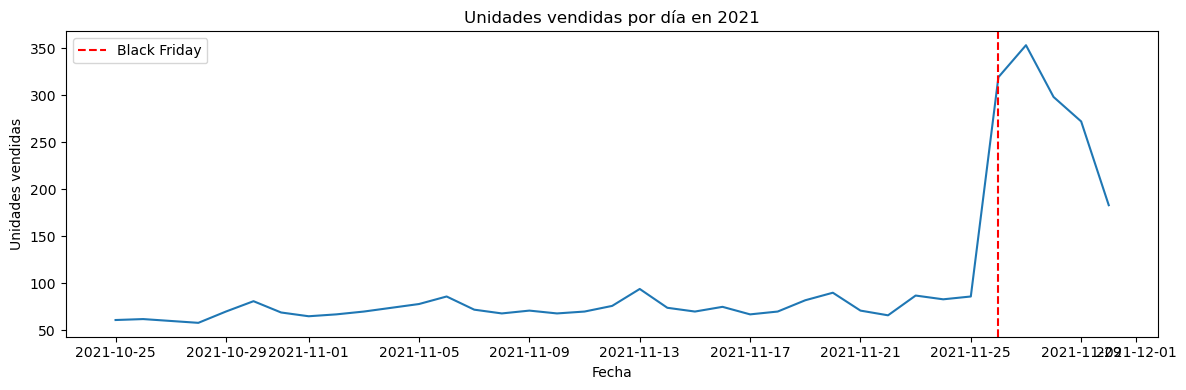

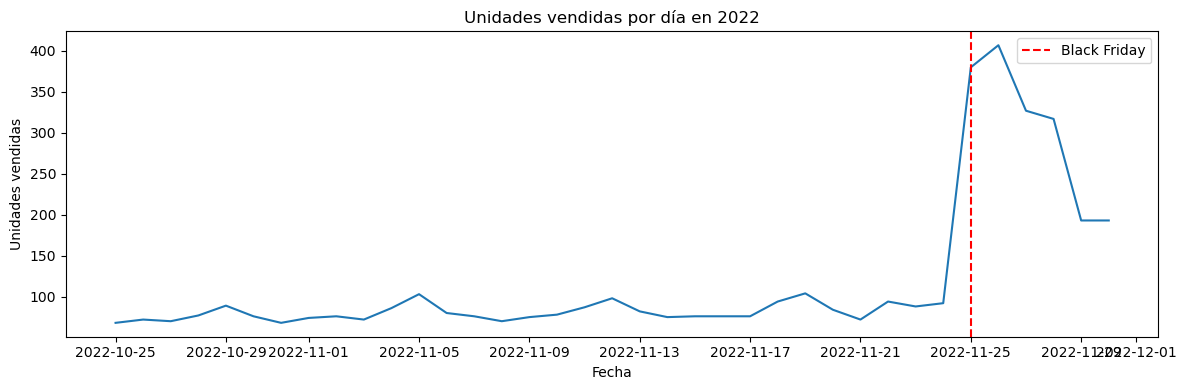

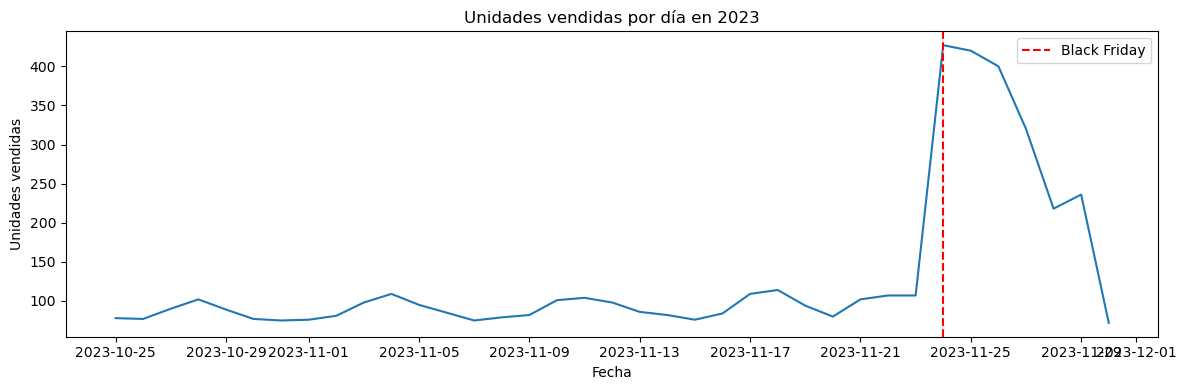

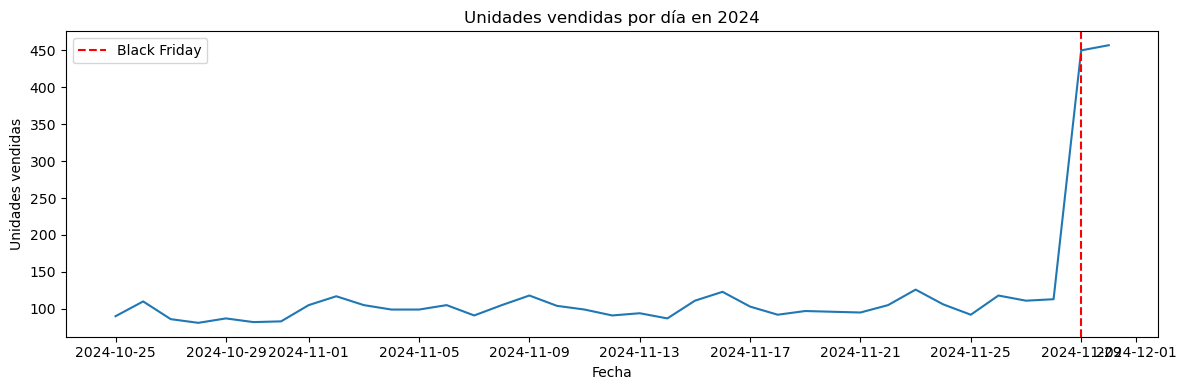

In [ ]:
# 🤖 Análisis temporal: suma de unidades vendidas por año con Black Fridayimport pandas as pd
import numpy as np
   import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.holiday import USFederalHolidayCalendar

# Asegurarse de que la columna fecha es datetime
df['fecha'] = pd.to_datetime(df['fecha'])
df['año'] = df['fecha'].dt.year

# Fechas de Black Friday (último viernes de noviembre)
def get_black_fridays(years):
    bfs = []
    for y in years:
        nov = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        bfs.append(fridays[-1])
    return bfs

years = df['año'].unique()
black_fridays = get_black_fridays(years)

# Graficar por año
for y in sorted(years):
    plt.figure(figsize=(12,4))
    data = df[df['año']==y].groupby('fecha')['unidades_vendidas'].sum().reset_index()
    sns.lineplot(data=data, x='fecha', y='unidades_vendidas')
    # Marcar Black Friday
    bf = [d for d in black_fridays if d.year==y]
    for bfd in bf:
        plt.axvline(bfd, color='red', linestyle='--', label='Black Friday')
    plt.title(f'Unidades vendidas por día en {y}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\Windows\AppData\Local\Temp\ipykernel_8864\4006309227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('dia_semana', sort=False)['unidades_vendidas'].sum().reindex([


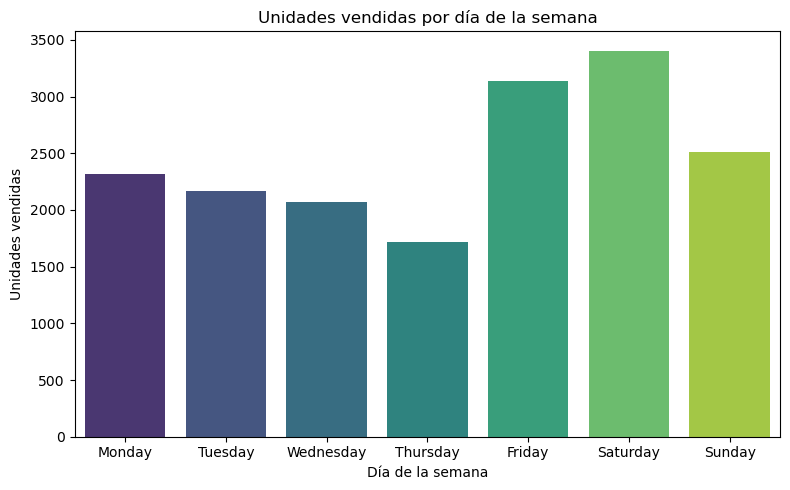

In [46]:
# 🤖 Unidades vendidas por día de la semana
plt.figure(figsize=(8,5))
sns.barplot(data=df.groupby('dia_semana', sort=False)['unidades_vendidas'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).reset_index(), x='dia_semana', y='unidades_vendidas', palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

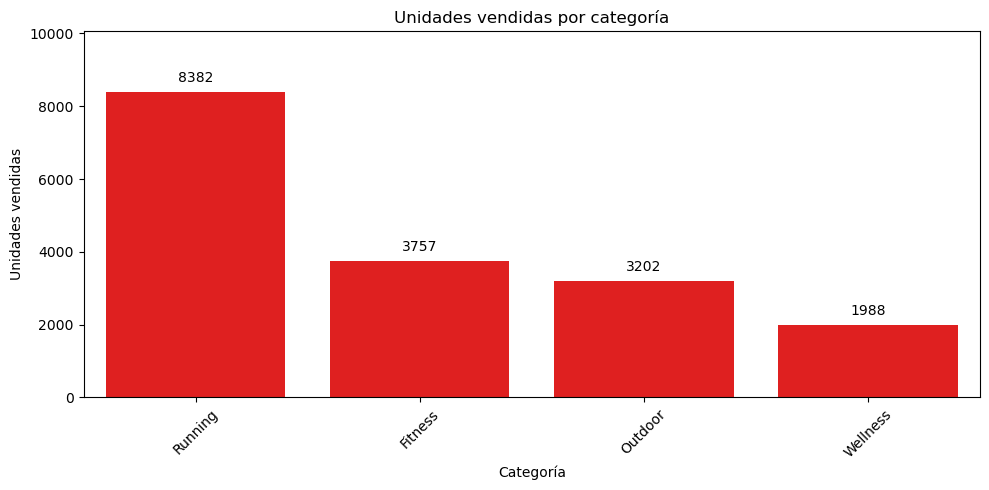

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🤖 Unidades vendidas por categoría
plt.figure(figsize=(10,5))

data_cat = df.groupby('categoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False)

ax = sns.barplot(
    data=data_cat,
    x='categoria',
    y='unidades_vendidas',
    color='red'
)

# 1. AÑADIR MARGEN SUPERIOR (Esto evita que la etiqueta choque con el borde)
# El valor 0.2 añade un 20% de espacio extra arriba.
ax.margins(y=0.2)

# 2. AÑADIR ETIQUETAS DE DATOS
# padding=5 separa un poco el texto de la barra
ax.bar_label(ax.containers[0], padding=5, fontsize=10)

plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\Windows\AppData\Local\Temp\ipykernel_8864\701431387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),


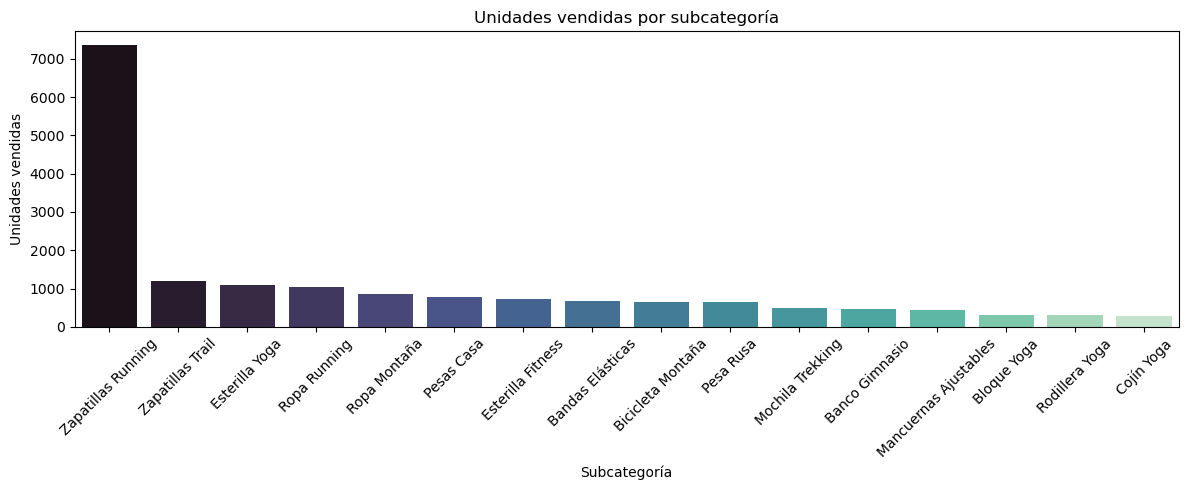

In [48]:
# 🤖 Unidades vendidas por subcategoría
plt.figure(figsize=(12,5))
sns.barplot(data=df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),
            x='subcategoria', y='unidades_vendidas', palette='mako')
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Windows\AppData\Local\Temp\ipykernel_8864\4291307181.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_productos, x='nombre', y='unidades_vendidas', palette='flare')


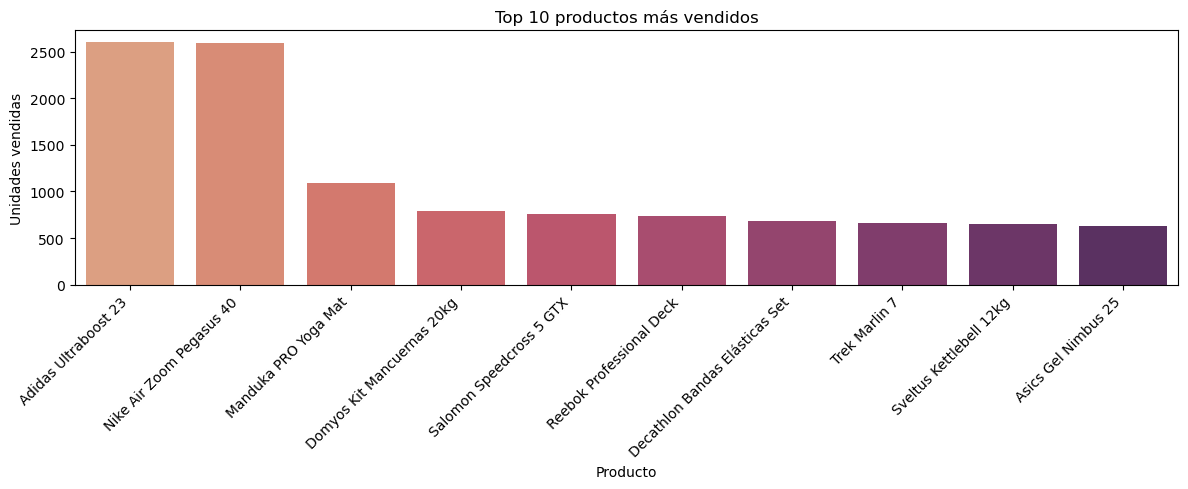

In [49]:
# 🤖 Top 10 productos más vendidos
plt.figure(figsize=(12,5))
top_productos = df.groupby(['producto_id','nombre'])['unidades_vendidas'].sum().reset_index()
top_productos = top_productos.sort_values('unidades_vendidas', ascending=False).head(10)
sns.barplot(data=top_productos, x='nombre', y='unidades_vendidas', palette='flare')
plt.title('Top 10 productos más vendidos')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

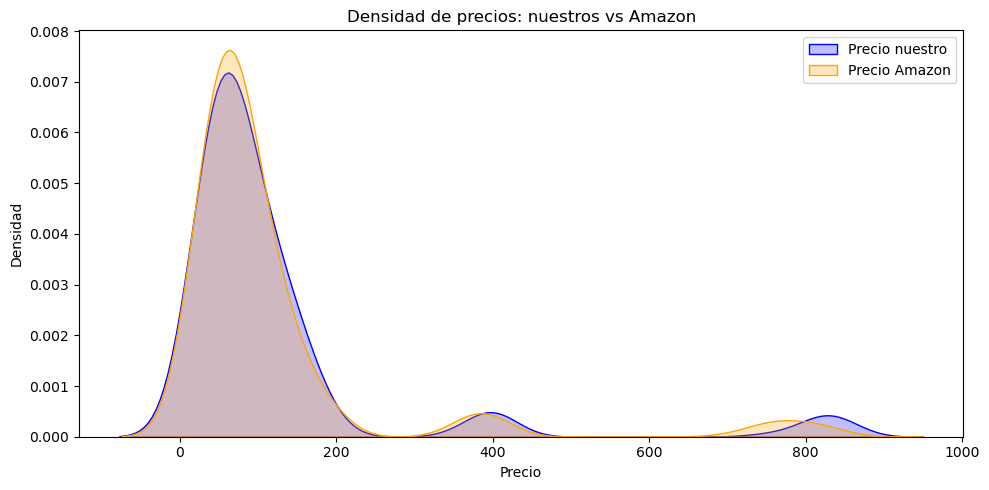

In [ ]:
# 🤖 Análisis de densidad de precios: nuestros vs Amazon
df = df.copy()
plt.figure(figsize=(10,5))
sns.kdeplot(df['precio_venta'], label='Precio nuestro', fill=True, color='blue')
if 'Amazon' in df.columns:
    sns.kdeplot(df['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de precios: nuestros vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 🤖 Crear variables temporales sobre df usando holidays para España
spain_holidays = holidays.Spain()

# Variables básicas de fecha
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['mes_nombre'] = df['fecha'].dt.month_name()
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()
df['dia_semana_num'] = df['fecha'].dt.weekday

# Fin de semana / festivo / lectivo
df['es_fin_de_semana'] = df['dia_semana_num'] >= 5
df['es_festivo'] = df['fecha'].isin(spain_holidays)
df['nombre_festivo'] = df['fecha'].map(spain_holidays)
df['es_dia_lectivo'] = ~df['es_festivo'] & ~df['es_fin_de_semana']

# Periodos del mes y año
df['trimestre'] = df['fecha'].dt.quarter
df['semana_año'] = df['fecha'].dt.isocalendar().week
df['es_inicio_mes'] = df['dia_mes'] <= 7
df['es_primer_dia_mes'] = df['dia_mes'] == 1
df['es_fin_mes'] = df['dia_mes'] >= 25
df['es_ultimo_dia_mes'] = df['fecha'] == (df['fecha'] + pd.offsets.MonthEnd(0))

def get_last_friday(year):
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    fridays = nov[nov.weekday == 4]
    return fridays[-1] if len(fridays) else None

black_fridays = [get_last_friday(year) for year in df['año'].unique()]
black_fridays = [d for d in black_fridays if d is not None]
cyber_mondays = [d + pd.Timedelta(days=3) for d in black_fridays]

# Eventos especiales de ecommerce
df['black_friday'] = df['fecha'].isin(black_fridays)
df['cyber_monday'] = df['fecha'].isin(cyber_mondays)

df['es_ultimo_tramo_mes'] = df['dia_mes'] >= 24

print('Variables temporales añadidas a df:')
display(df[[
    'fecha','año','mes','mes_nombre','dia_mes','dia_semana','es_fin_de_semana',
    'es_festivo','black_friday','cyber_monday','es_fin_mes'
]].head())

Variables temporales añadidas a df:


,fecha,año,mes,mes_nombre,dia_mes,dia_semana,es_fin_de_semana,es_festivo,black_friday,cyber_monday,es_fin_mes
0,2021-10-25,2021,10,October,25,Monday,False,False,False,False,True
1,2021-10-25,2021,10,October,25,Monday,False,False,False,False,True
2,2021-10-25,2021,10,October,25,Monday,False,False,False,False,True
3,2021-10-25,2021,10,October,25,Monday,False,False,False,False,True
4,2021-10-25,2021,10,October,25,Monday,False,False,False,False,True


In [52]:
df.shape

(2880, 40)

In [54]:
# 🤖 Crear lags de unidades vendidas (1 a 7) y media móvil de 7 días por año y producto

df = df.sort_values(['producto_id', 'año', 'fecha']).reset_index(drop=True)

for lag in range(1, 8):
    df[f'unidades_vendidas_lag_{lag}'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].shift(lag)

df['unidades_vendidas_roll_7'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'] \
    .transform(lambda x: x.rolling(window=7, min_periods=7).mean())

nuevas = [f'unidades_vendidas_lag_{lag}' for lag in range(1, 8)] + ['unidades_vendidas_roll_7']
df = df.dropna(subset=nuevas).reset_index(drop=True)

print('Lags y media móvil creados. Filas restantes:', len(df))
display(df[['fecha','producto_id','nombre'] + nuevas].head(10))

Lags y media móvil creados. Filas restantes: 2208


,fecha,producto_id,nombre,unidades_vendidas_lag_1,unidades_vendidas_lag_2,unidades_vendidas_lag_3,unidades_vendidas_lag_4,unidades_vendidas_lag_5,unidades_vendidas_lag_6,unidades_vendidas_lag_7,unidades_vendidas_roll_7
0,2021-11-08,PROD_001,Nike Air Zoom Pegasus 40,10.0,10.0,10.0,12.0,11.0,10.0,7.0,10.285714
1,2021-11-09,PROD_001,Nike Air Zoom Pegasus 40,9.0,10.0,10.0,10.0,12.0,11.0,10.0,10.428571
2,2021-11-10,PROD_001,Nike Air Zoom Pegasus 40,11.0,9.0,10.0,10.0,10.0,12.0,11.0,10.285714
3,2021-11-11,PROD_001,Nike Air Zoom Pegasus 40,10.0,11.0,9.0,10.0,10.0,10.0,12.0,10.000000
4,2021-11-12,PROD_001,Nike Air Zoom Pegasus 40,10.0,10.0,11.0,9.0,10.0,10.0,10.0,10.142857
5,2021-11-13,PROD_001,Nike Air Zoom Pegasus 40,11.0,10.0,10.0,11.0,9.0,10.0,10.0,11.142857
6,2021-11-14,PROD_001,Nike Air Zoom Pegasus 40,17.0,11.0,10.0,10.0,11.0,9.0,10.0,11.000000
7,2021-11-15,PROD_001,Nike Air Zoom Pegasus 40,9.0,17.0,11.0,10.0,10.0,11.0,9.0,11.428571
8,2021-11-16,PROD_001,Nike Air Zoom Pegasus 40,12.0,9.0,17.0,11.0,10.0,10.0,11.0,11.428571
9,2021-11-17,PROD_001,Nike Air Zoom Pegasus 40,11.0,12.0,9.0,17.0,11.0,10.0,10.0,11.428571


In [55]:
df.shape

(2208, 40)

In [56]:
df.groupby('año').size()

año
2021    552
2022    552
2023    552
2024    552
dtype: int64

In [57]:
# 🤖 Calcular descuento porcentual al final del notebook

df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

print('Descuento porcentual calculado al final del notebook:')
display(df[[
    'fecha','producto_id','nombre','precio_base','precio_venta','descuento_porcentaje'
]].head())

Descuento porcentual calculado al final del notebook:


,fecha,producto_id,nombre,precio_base,precio_venta,descuento_porcentaje
0,2021-11-08,PROD_001,Nike Air Zoom Pegasus 40,115,113.46,-1.339130
1,2021-11-09,PROD_001,Nike Air Zoom Pegasus 40,115,113.98,-0.886957
2,2021-11-10,PROD_001,Nike Air Zoom Pegasus 40,115,117.57,2.234783
3,2021-11-11,PROD_001,Nike Air Zoom Pegasus 40,115,118.11,2.704348
4,2021-11-12,PROD_001,Nike Air Zoom Pegasus 40,115,112.34,-2.313043


In [58]:
# 🤖 Calcular precio de competencia y ratio de precios al final del notebook

df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

print('Precio promedio de competencia y ratio de precio calculados:')
display(df[[
    'fecha','producto_id','nombre','precio_venta','precio_competencia','ratio_precio'
]].head())

# Eliminar columnas de competidores individuales
df = df.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

Precio promedio de competencia y ratio de precio calculados:


,fecha,producto_id,nombre,precio_venta,precio_competencia,ratio_precio
0,2021-11-08,PROD_001,Nike Air Zoom Pegasus 40,113.46,97.003333,1.169651
1,2021-11-09,PROD_001,Nike Air Zoom Pegasus 40,113.98,96.933333,1.175860
2,2021-11-10,PROD_001,Nike Air Zoom Pegasus 40,117.57,96.343333,1.220323
3,2021-11-11,PROD_001,Nike Air Zoom Pegasus 40,118.11,96.626667,1.222333
4,2021-11-12,PROD_001,Nike Air Zoom Pegasus 40,112.34,95.240000,1.179546


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     2208 non-null   datetime64[us]
 1   producto_id               2208 non-null   str           
 2   nombre                    2208 non-null   str           
 3   categoria                 2208 non-null   str           
 4   subcategoria              2208 non-null   str           
 5   precio_base               2208 non-null   int64         
 6   es_estrella               2208 non-null   bool          
 7   unidades_vendidas         2208 non-null   int64         
 8   precio_venta              2208 non-null   float64       
 9   ingresos                  2208 non-null   float64       
 10  año                       2208 non-null   int32         
 11  mes                       2208 non-null   int32         
 12  mes_nombre                2208 

In [60]:
# 🤖 Crear copias con sufijo _h y aplicar one-hot encoding

df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One-hot encoding para las copias *_h
dummies = pd.get_dummies(df[['nombre_h','categoria_h','subcategoria_h']].astype(str), prefix=['nombre_h','categoria_h','subcategoria_h'])
df = pd.concat([df, dummies], axis=1)

print('One-hot encoding aplicado. Columnas añadidas (ejemplo):')
print(list(dummies.columns)[:20])
display(df.head()[['fecha','producto_id','nombre_h','categoria_h','subcategoria_h'] + list(dummies.columns)[:5]])

One-hot encoding aplicado. Columnas añadidas (ejemplo):
['nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad', 'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat', 'nombre_h_Merrell Moab 2 GTX', 'nombre_h_New Balance Fresh Foam X 1080v12', 'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler', 'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500', 'nombre_h_Reebok Floatride Energy 5', 'nombre_h_Reebok Professional Deck']


,fecha,producto_id,nombre_h,categoria_h,subcategoria_h,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge
0,2021-11-08,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,False,False,False,False,False
1,2021-11-09,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,False,False,False,False,False
2,2021-11-10,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,False,False,False,False,False
3,2021-11-11,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,False,False,False,False,False
4,2021-11-12,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,False,False,False,False,False


In [61]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-11-08,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,9,113.46,1021.14,...,False,False,False,False,False,False,False,False,True,False
1,2021-11-09,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,113.98,1253.78,...,False,False,False,False,False,False,False,False,True,False
2,2021-11-10,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,117.57,1175.70,...,False,False,False,False,False,False,False,False,True,False
3,2021-11-11,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,118.11,1181.10,...,False,False,False,False,False,False,False,False,True,False
4,2021-11-12,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,112.34,1235.74,...,False,False,False,False,False,False,False,False,True,False


In [63]:
# 🤖 Guardar df procesado en data/processed
from pathlib import Path
output_dir = Path('..') / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'df.csv'
df.to_csv(output_path, index=False, encoding='utf-8')
print(f'Guardado df  en: {output_path}')

Guardado df  en: ..\data\processed\df.csv


In [65]:
# 🤖 Dividir df en train y validation por año
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print('Registros en train_df (2021-2023):', len(train_df))
print('Registros en validation_df (2024):', len(validation_df))

counts = pd.DataFrame({
    'conjunto': ['train', 'validation'],
    'registros': [len(train_df), len(validation_df)]
})

display(counts)

Registros en train_df (2021-2023): 1656
Registros en validation_df (2024): 552


,conjunto,registros
0,train,1656
1,validation,552


In [67]:
# 🤖 Entrenar HistGradientBoostingRegressor conservador
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

exclude_cols = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols = [c for c in train_df.select_dtypes(exclude=['object']).columns if c not in exclude_cols]

X_train = train_df[X_cols]
y_train = train_df['unidades_vendidas']
X_val = validation_df[X_cols]
y_val = validation_df['unidades_vendidas']

model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=6,
    l2_regularization=1.0,
    min_samples_leaf=20,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

y_naive = np.full(shape=len(y_val), fill_value=y_train.mean())

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

mape = np.mean(np.abs((y_val - y_pred) / np.where(y_val == 0, 1, y_val))) * 100
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_naive)
rmse_naive = np.sqrt(mean_squared_error(y_val, y_naive))

mape_naive = np.mean(np.abs((y_val - y_naive) / np.where(y_val == 0, 1, y_val))) * 100
r2_naive = r2_score(y_val, y_naive)

results = pd.DataFrame({
    'modelo': ['HistGradientBoosting', 'Naive mean'],
    'MAE': [mae, mae_naive],
    'RMSE': [rmse, rmse_naive],
    'MAPE (%)': [mape, mape_naive],
    'R2': [r2, r2_naive]
})

print('Métricas de validación para el modelo y el baseline naive:')
display(results)

Métricas de validación para el modelo y el baseline naive:


,modelo,MAE,RMSE,MAPE (%),R2
0,HistGradientBoosting,0.919779,2.220873,17.606291,0.906977
1,Naive mean,4.176013,7.284684,106.672152,-0.000842


In [75]:
# 🤖 Reentrenar modelo con todos los datos disponibles de 2021 a 2024
full_train_df = df[df['año'].isin([2021, 2022, 2023, 2024])].copy()

exclude_cols = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols = [c for c in full_train_df.select_dtypes(exclude=['object']).columns if c not in exclude_cols]
X_full = full_train_df[X_cols]
y_full = full_train_df['unidades_vendidas']

model_full_df = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=6,
    l2_regularization=1.0,
    min_samples_leaf=20,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

model_full_df.fit(X_full, y_full)

print(f'Reentrenado modelo con df completo (2021-2024): {len(full_train_df)} registros.')

Reentrenado modelo con df completo (2021-2024): 2208 registros.


Modelo guardado en: ..\models\model_full_df.joblib


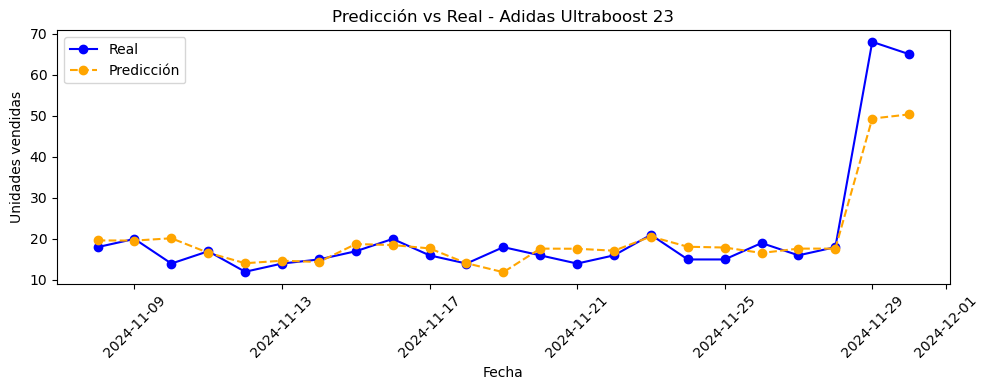

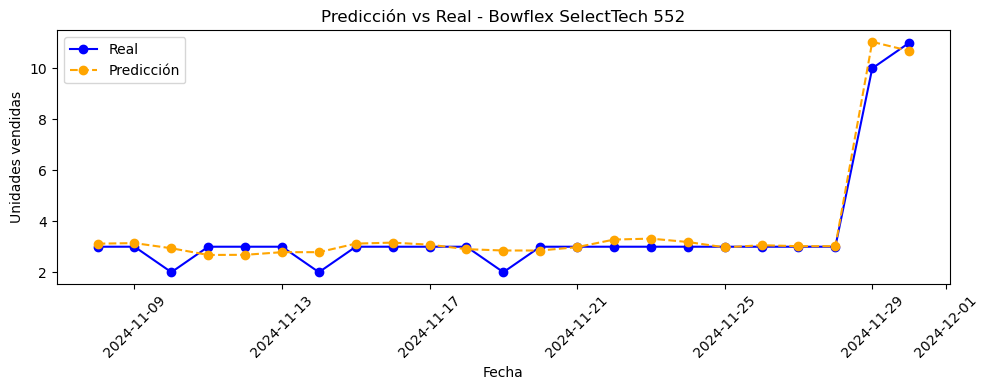

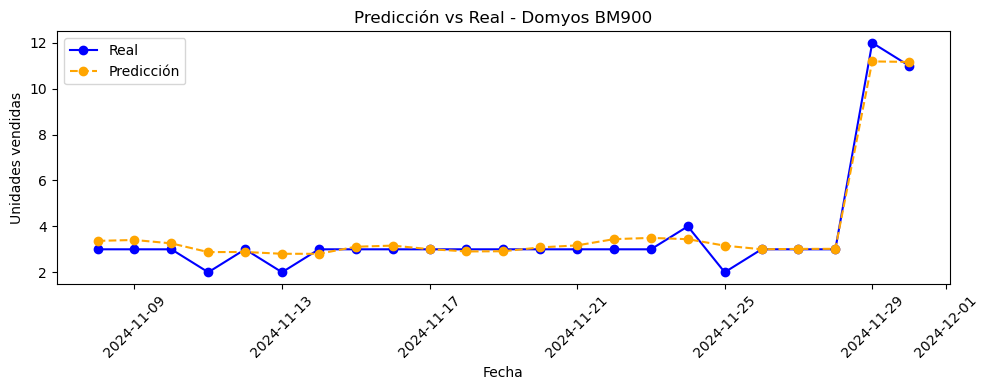

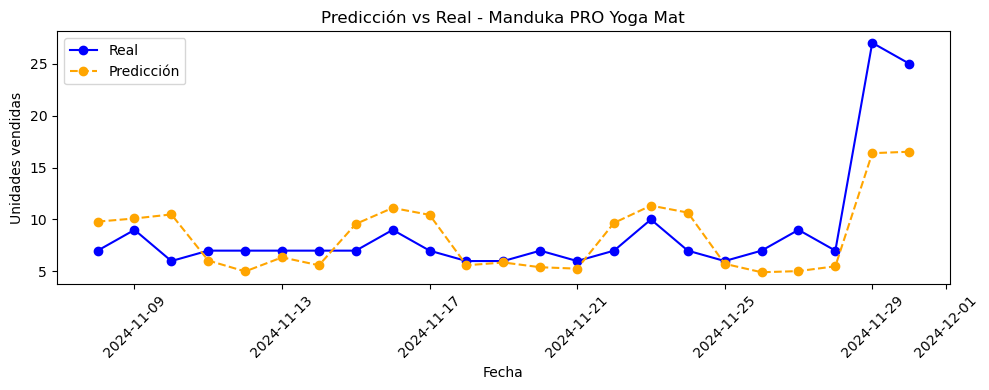

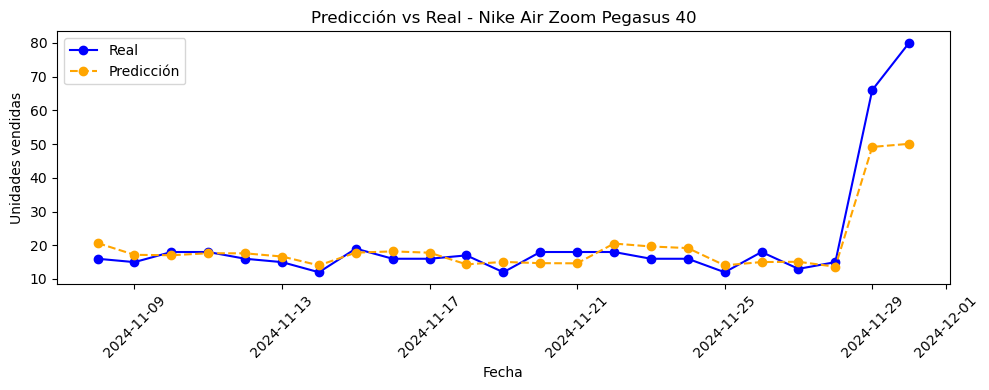

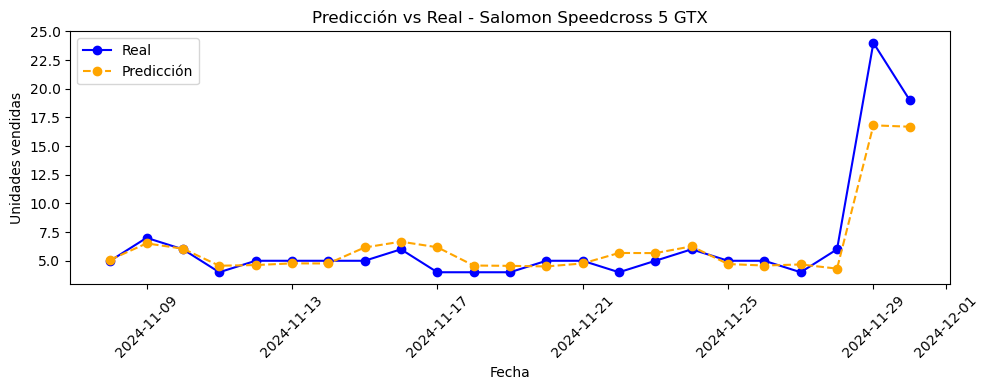

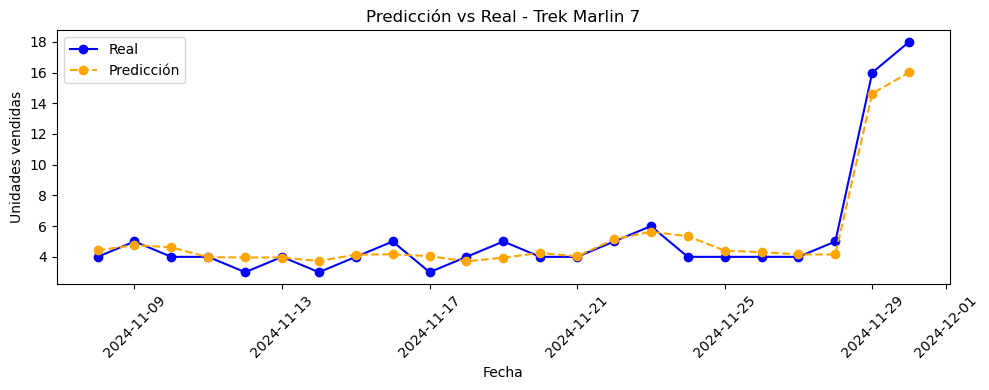

In [76]:
# 🤖 Guardar el modelo reentrenado en models/ y luego ejecutar predicciones de noviembre
from pathlib import Path
import joblib

models_dir = Path('..') / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'model_full_df.joblib'
joblib.dump(model_full_df, model_path)
print(f'Modelo guardado en: {model_path}')

# 🤖 Predicciones para noviembre de 2024 y gráficos por producto estrella
nov_2024 = df[(df['año'] == 2024) & (df['mes'] == 11) & (df['es_estrella'] == True)].copy()

if 'X_cols' not in globals():
    exclude_cols = ['fecha', 'ingresos', 'unidades_vendidas']
    X_cols = [c for c in train_df.select_dtypes(exclude=['object']).columns if c not in exclude_cols]

nov_2024 = nov_2024.sort_values(['nombre', 'fecha']).reset_index(drop=True)

for producto in nov_2024['nombre'].unique():
    producto_df = nov_2024[nov_2024['nombre'] == producto].copy()
    if producto_df.empty:
        continue

    X_nov = producto_df[X_cols]
    y_true = producto_df['unidades_vendidas']
    y_pred_nov = model.predict(X_nov)

    plt.figure(figsize=(10, 4))
    plt.plot(producto_df['fecha'], y_true, marker='o', label='Real', color='blue')
    plt.plot(producto_df['fecha'], y_pred_nov, marker='o', linestyle='--', label='Predicción', color='orange')
    plt.title(f'Predicción vs Real - {producto}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# 🤖 Calcular MAE por producto estrella en noviembre de 2024
mae_por_producto = []
for producto in nov_2024['nombre'].unique():
    producto_df = nov_2024[nov_2024['nombre'] == producto].copy()
    if producto_df.empty:
        continue

    y_true = producto_df['unidades_vendidas']
    y_pred_nov = model.predict(producto_df[X_cols])
    mae_prod = mean_absolute_error(y_true, y_pred_nov)
    mae_por_producto.append({
        'producto': producto,
        'MAE': mae_prod,
        'n_registros': len(producto_df)
    })

mae_productos_df = pd.DataFrame(mae_por_producto).sort_values('MAE')
print('MAE por producto estrella en noviembre de 2024:')
display(mae_productos_df)

In [ ]:
# 🤖 Calcular MAE por producto estrella en noviembre de 2024
mae_por_producto = []
for producto in nov_2024['nombre'].unique():
    producto_df = nov_2024[nov_2024['nombre'] == producto].copy()
    if producto_df.empty:
        continue

    y_true = producto_df['unidades_vendidas']
    y_pred_nov = model.predict(producto_df[X_cols])
    mae_prod = mean_absolute_error(y_true, y_pred_nov)
    mae_por_producto.append({
        'producto': producto,
        'MAE': mae_prod,
        'n_registros': len(producto_df)
    })

mae_productos_df = pd.DataFrame(mae_por_producto).sort_values('MAE')
print('MAE por producto estrella en noviembre de 2024:')
display(mae_productos_df)

In [69]:
# 🤖 Calcular MAE por producto estrella en noviembre de 2024
mae_por_producto = []
for producto in nov_2024['nombre'].unique():
    producto_df = nov_2024[nov_2024['nombre'] == producto].copy()
    if producto_df.empty:
        continue

    y_true = producto_df['unidades_vendidas']
    y_pred_nov = model.predict(producto_df[X_cols])
    mae_prod = mean_absolute_error(y_true, y_pred_nov)
    mae_por_producto.append({
        'producto': producto,
        'MAE': mae_prod,
        'n_registros': len(producto_df)
    })

mae_productos_df = pd.DataFrame(mae_por_producto).sort_values('MAE')
print('MAE por producto estrella en noviembre de 2024:')
display(mae_productos_df)


MAE por producto estrella en noviembre de 2024:


,producto,MAE,n_registros
1,Bowflex SelectTech 552,0.285967,23
2,Domyos BM900,0.322478,23
6,Trek Marlin 7,0.591457,23
5,Salomon Speedcross 5 GTX,1.003716,23
3,Manduka PRO Yoga Mat,2.563888,23
0,Adidas Ultraboost 23,3.202525,23
4,Nike Air Zoom Pegasus 40,4.155899,23


Métricas por periodo en noviembre de 2024:


,periodo,MAE,RMSE,MAPE,n_registros
0,1-10 Nov,1.356864,2.174851,17.198962,21
1,11-20 Nov,0.996075,1.456741,14.205754,70
2,21-30 Nov,2.581100,5.545999,15.220005,70


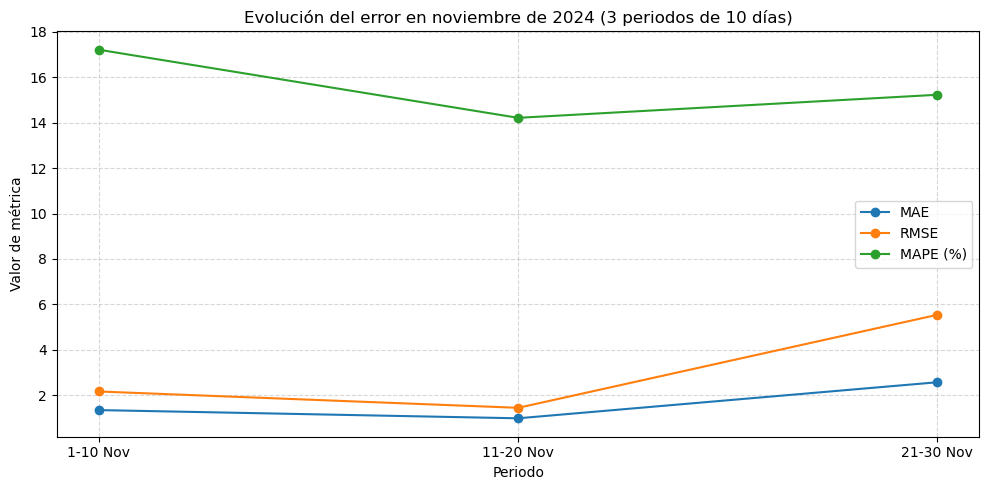

In [70]:
# 🤖 Analizar degradación del error durante noviembre de 2024 en tres periodos de 10 días
nov_2024 = nov_2024.copy()
nov_2024['periodo'] = pd.cut(
    nov_2024['dia_mes'],
    bins=[0, 10, 20, 30],
    labels=['1-10 Nov', '11-20 Nov', '21-30 Nov'],
    right=True,
    include_lowest=True
)

nov_2024 = nov_2024.sort_values(['periodo', 'fecha'])
nov_2024['prediccion'] = model.predict(nov_2024[X_cols])
nov_2024['error'] = nov_2024['unidades_vendidas'] - nov_2024['prediccion']
nov_2024['abserror'] = nov_2024['error'].abs()
nov_2024['ape'] = np.where(nov_2024['unidades_vendidas'] == 0, np.nan,
                            (nov_2024['abserror'] / nov_2024['unidades_vendidas']) * 100)

metrics_periodo = nov_2024.groupby('periodo').agg(
    MAE=('abserror', 'mean'),
    RMSE=('error', lambda x: np.sqrt((x**2).mean())),
    MAPE=('ape', 'mean'),
    n_registros=('unidades_vendidas', 'size')
).reset_index()

print('Métricas por periodo en noviembre de 2024:')
display(metrics_periodo)

plt.figure(figsize=(10, 5))
plt.plot(metrics_periodo['periodo'], metrics_periodo['MAE'], marker='o', label='MAE')
plt.plot(metrics_periodo['periodo'], metrics_periodo['RMSE'], marker='o', label='RMSE')
plt.plot(metrics_periodo['periodo'], metrics_periodo['MAPE'], marker='o', label='MAPE (%)')
plt.title('Evolución del error en noviembre de 2024 (3 periodos de 10 días)')
plt.xlabel('Periodo')
plt.ylabel('Valor de métrica')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 🤖 Graficar la evolución del MAE por producto estrella en noviembre de 2024
mae_periodo_producto = []
for (periodo, producto), grupo in nov_2024.groupby(['periodo', 'nombre']):
    if grupo.empty:
        continue

    y_true = grupo['unidades_vendidas']
    y_pred = model.predict(grupo[X_cols])
    mae_periodo_producto.append({
        'periodo': periodo,
        'producto': producto,
        'MAE': mean_absolute_error(y_true, y_pred),
        'n_registros': len(grupo)
    })

mae_periodo_producto_df = pd.DataFrame(mae_periodo_producto)
mae_periodo_producto_df['periodo'] = pd.Categorical(
    mae_periodo_producto_df['periodo'],
    categories=['1-10 Nov', '11-20 Nov', '21-30 Nov'],
    ordered=True
)
mae_periodo_producto_df = mae_periodo_producto_df.sort_values(['producto', 'periodo'])

print('MAE por producto estrella y periodo en noviembre de 2024:')
display(mae_periodo_producto_df)

plt.figure(figsize=(14, 7))
for producto, grupo in mae_periodo_producto_df.groupby('producto'):
    plt.plot(grupo['periodo'], grupo['MAE'], marker='o', label=producto)

plt.title('Evolución del MAE por producto estrella en noviembre de 2024')
plt.xlabel('Periodo')
.ylabel('MAE')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

In [ ]:
# 🤖 Graficar la evolución del MAE por producto estrella en noviembre de 2024
mae_periodo_producto = []
for (periodo, producto), grupo in nov_2024.groupby(['periodo', 'nombre']):
    if grupo.empty:
        continue
    y_true = grupo['unidades_vendidas']
    y_pred = model.predict(grupo[X_cols])
    mae_periodo_producto.append({
        'periodo': periodo,
        'producto': producto,
        'MAE': mean_absolute_error(y_true, y_pred),
        'n_registros': len(grupo)
    })

mae_periodo_producto_df = pd.DataFrame(mae_periodo_producto)
mae_periodo_producto_df['periodo'] = pd.Categorical(
    mae_periodo_producto_df['periodo'],
    categories=['1-10 Nov', '11-20 Nov', '21-30 Nov'],
    ordered=True
)
mae_periodo_producto_df = mae_periodo_producto_df.sort_values(['producto', 'periodo'])

print('MAE por producto estrella y periodo en noviembre de 2024:')
display(mae_periodo_producto_df)

plt.figure(figsize=(14, 7))
for producto, grupo in mae_periodo_producto_df.groupby('producto'):
    plt.plot(grupo['periodo'], grupo['MAE'], marker='o', label=producto)

plt.title('Evolución del MAE por producto estrella en noviembre de 2024')
plt.xlabel('Periodo')
plt.ylabel('MAE')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

Black Friday 2024: real vs predicho por producto_id


,producto_id,nombre,unidades_vendidas_real,unidades_vendidas_pred
0,PROD_001,Nike Air Zoom Pegasus 40,66.0,49.141730
1,PROD_002,Adidas Ultraboost 23,68.0,49.314872
2,PROD_003,Asics Gel Nimbus 25,18.0,14.555055
3,PROD_004,New Balance Fresh Foam X 1080v12,14.0,13.480720
4,PROD_005,Nike Dri-FIT Miler,14.0,13.623522
5,PROD_006,Adidas Own The Run Jacket,12.0,13.464748
6,PROD_007,Puma Velocity Nitro 2,13.0,11.402513
7,PROD_008,Reebok Floatride Energy 5,12.0,11.402513
8,PROD_009,Bowflex SelectTech 552,10.0,11.039060
9,PROD_010,Domyos BM900,12.0,11.189299


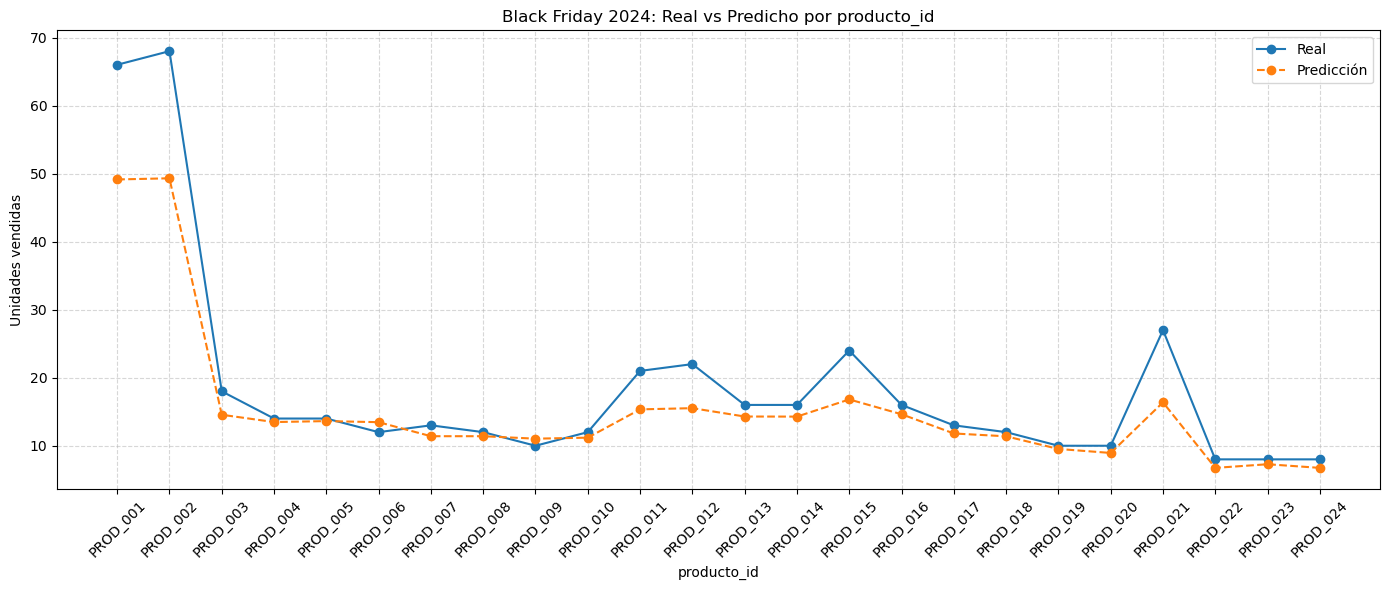

In [72]:
# 🤖 Análisis Black Friday 2024: real vs predicho por producto_id
bf_2024 = df[(df['año'] == 2024) & (df['black_friday'])].copy()
if bf_2024.empty:
    print('No hay datos de Black Friday 2024 en el dataframe.')
else:
    bf_2024 = bf_2024.sort_values('producto_id').reset_index(drop=True)
    bf_2024['prediccion'] = model.predict(bf_2024[X_cols])

    bf_summary = bf_2024.groupby(['producto_id', 'nombre'], as_index=False).agg(
        unidades_vendidas_real=('unidades_vendidas', 'mean'),
        unidades_vendidas_pred=('prediccion', 'mean')
    ).sort_values('producto_id')

    print('Black Friday 2024: real vs predicho por producto_id')
    display(bf_summary)

    plt.figure(figsize=(14, 6))
    x_labels = bf_summary['producto_id'].astype(str)
    plt.plot(x_labels, bf_summary['unidades_vendidas_real'], marker='o', label='Real')
    plt.plot(x_labels, bf_summary['unidades_vendidas_pred'], marker='o', linestyle='--', label='Predicción')
    plt.title('Black Friday 2024: Real vs Predicho por producto_id')
    plt.xlabel('producto_id')
    plt.ylabel('Unidades vendidas')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

MAE por producto estrella y periodo en noviembre de 2024:


,periodo,producto,MAE,n_registros
0,1-10 Nov,Adidas Ultraboost 23,2.733558,3
7,11-20 Nov,Adidas Ultraboost 23,1.653593,10
14,21-30 Nov,Adidas Ultraboost 23,4.892148,10
1,1-10 Nov,Bowflex SelectTech 552,0.400391,3
8,11-20 Nov,Bowflex SelectTech 552,0.310019,10
15,21-30 Nov,Bowflex SelectTech 552,0.227588,10
2,1-10 Nov,Domyos BM900,0.344083,3
9,11-20 Nov,Domyos BM900,0.253604,10
16,21-30 Nov,Domyos BM900,0.384871,10
3,1-10 Nov,Manduka PRO Yoga Mat,2.791200,3


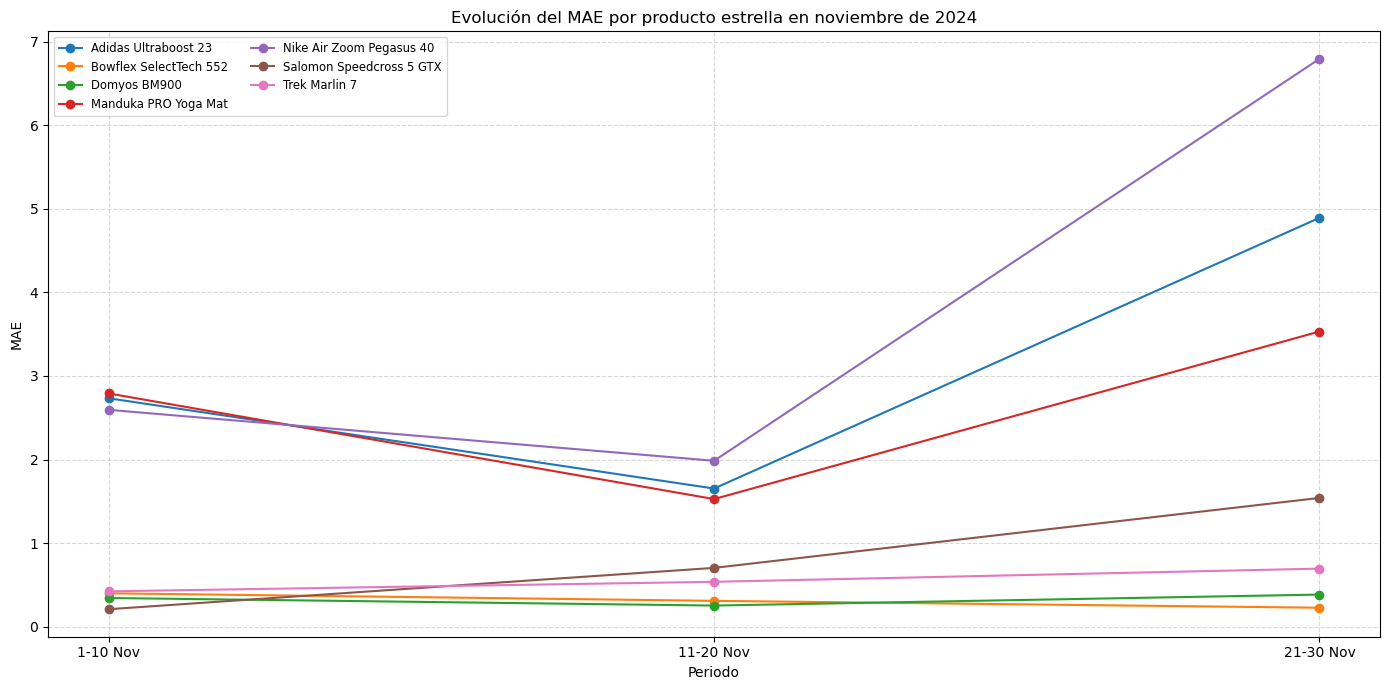

In [71]:
# 🤖 Graficar la evolución del MAE por producto estrella en noviembre de 2024
mae_periodo_producto = []
for (periodo, producto), grupo in nov_2024.groupby(["periodo", "nombre"]):
    if grupo.empty:
        continue

    y_true = grupo["unidades_vendidas"]
    y_pred = model.predict(grupo[X_cols])
    mae_periodo_producto.append({
        "periodo": periodo,
        "producto": producto,
        "MAE": mean_absolute_error(y_true, y_pred),
        "n_registros": len(grupo)
    })

mae_periodo_producto_df = pd.DataFrame(mae_periodo_producto)
mae_periodo_producto_df["periodo"] = pd.Categorical(mae_periodo_producto_df["periodo"], categories=["1-10 Nov", "11-20 Nov", "21-30 Nov"], ordered=True)
mae_periodo_producto_df = mae_periodo_producto_df.sort_values(["producto", "periodo"])

print("MAE por producto estrella y periodo en noviembre de 2024:")
display(mae_periodo_producto_df)

plt.figure(figsize=(14, 7))
for producto, grupo in mae_periodo_producto_df.groupby("producto"):
    plt.plot(grupo["periodo"], grupo["MAE"], marker="o", label=producto)

plt.title("Evolución del MAE por producto estrella en noviembre de 2024")
plt.xlabel("Periodo")
plt.ylabel("MAE")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()


Top 30 features por importancia (permutation importance, modelo final):


,feature,importance_mean,importance_std,importance_abs
0,unidades_vendidas_roll_7,2.973934,0.026852,2.973934
1,descuento_porcentaje,0.850967,0.015763,0.850967
2,unidades_vendidas_lag_1,0.654170,0.010412,0.654170
3,dia_semana_num,0.235482,0.008283,0.235482
4,black_friday,0.187388,0.005412,0.187388
5,unidades_vendidas_lag_4,0.128802,0.006227,0.128802
6,unidades_vendidas_lag_2,0.112039,0.004620,0.112039
7,unidades_vendidas_lag_7,0.104645,0.011311,0.104645
8,dia_mes,0.094804,0.003614,0.094804
9,unidades_vendidas_lag_6,0.033576,0.002417,0.033576


C:\Users\Windows\AppData\Local\Temp\ipykernel_8864\1328347670.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_abs', y='feature', data=imp_df, palette='viridis')


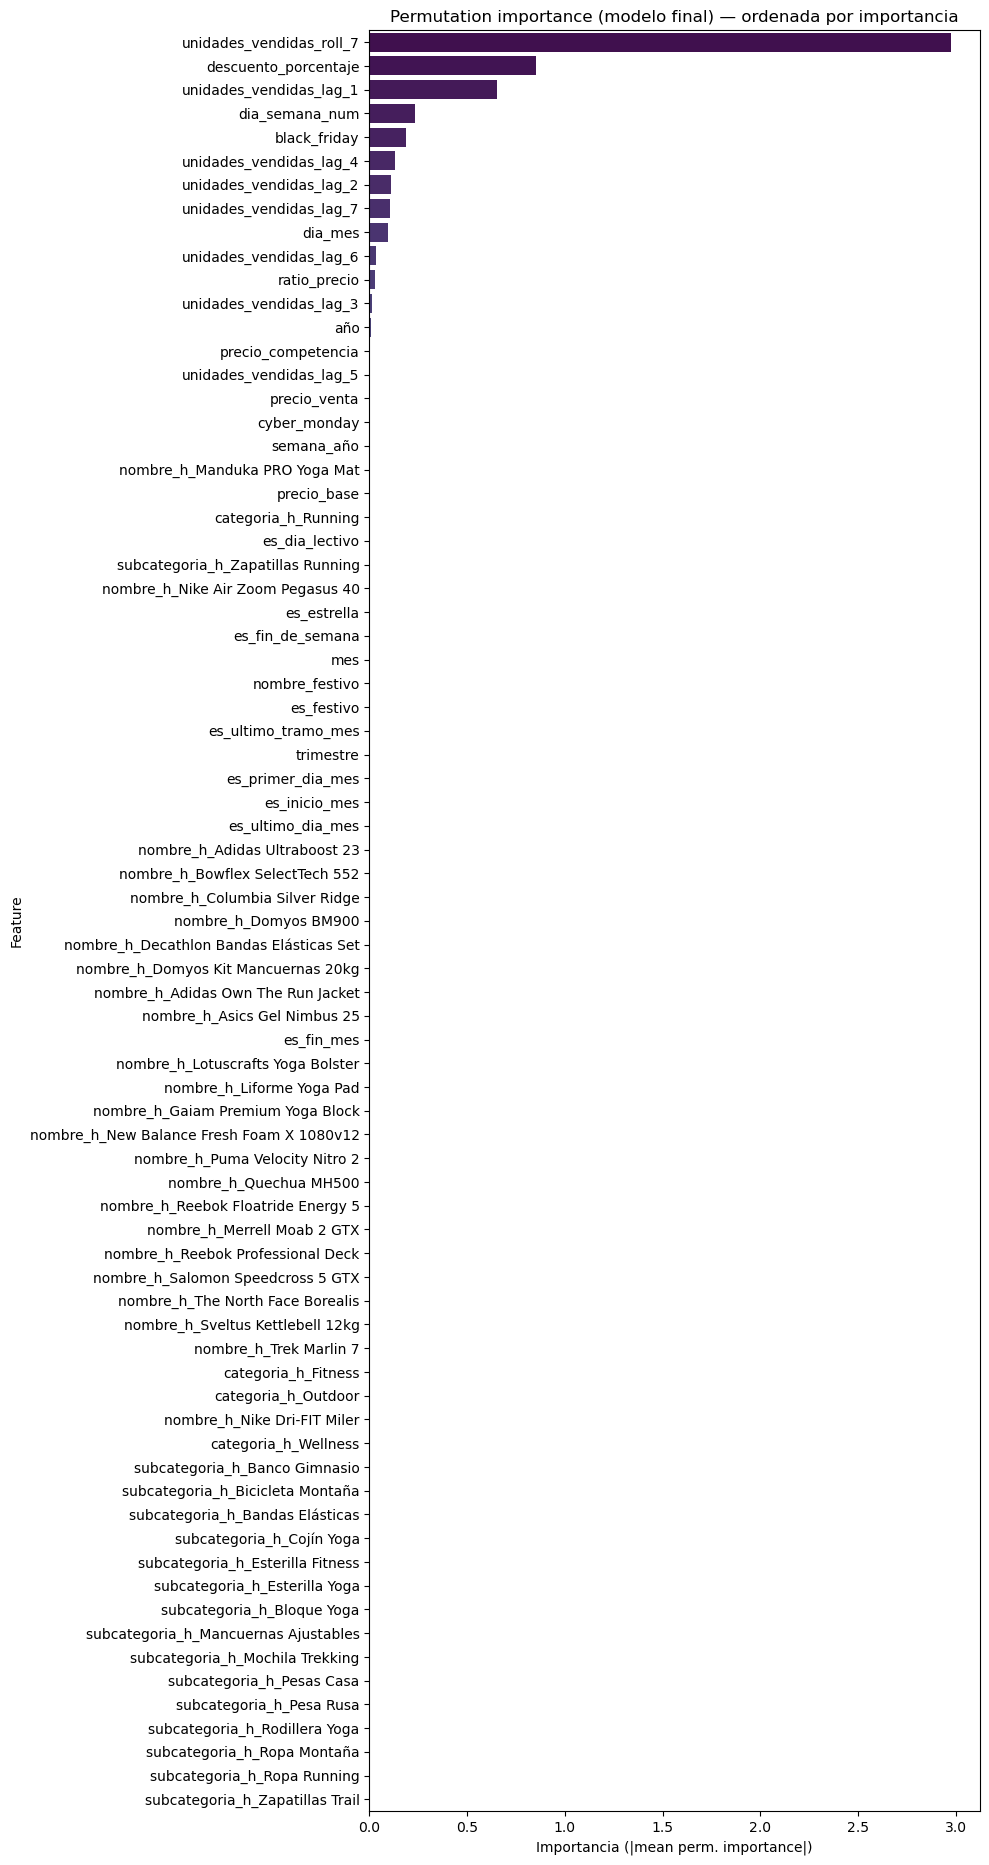

In [77]:
# 🤖 Calcular permutation importance del modelo final y graficar
from sklearn.inspection import permutation_importance

# Asegurarnos de usar las mismas X/y que se usaron para reentrenar
# `model_full_df`, `X_full`, `y_full` deben existir en el kernel
res_perm = permutation_importance(
    model_full_df,
    X_full,
    y_full,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

imp_df = pd.DataFrame({
    'feature': X_full.columns,
    'importance_mean': res_perm.importances_mean,
    'importance_std': res_perm.importances_std
})

# Usar el valor absoluto para ordenar por magnitud de impacto
imp_df['importance_abs'] = imp_df['importance_mean'].abs()
imp_df = imp_df.sort_values('importance_abs', ascending=False).reset_index(drop=True)

print('Top 30 features por importancia (permutation importance, modelo final):')
display(imp_df.head(30))

# Gráfico de barras horizontales ordenadas
plt.figure(figsize=(10, max(6, 0.25 * len(imp_df))))
sns.barplot(x='importance_abs', y='feature', data=imp_df, palette='viridis')
plt.xlabel('Importancia (|mean perm. importance|)')
plt.ylabel('Feature')
plt.title('Permutation importance (modelo final) — ordenada por importancia')
plt.tight_layout()
plt.show()